# Neural Networks with PyTorch — XOR Problem (SOLUTION)

## Step 1: Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| device:', device)

PyTorch: 2.12.0 | device: mps


## Step 2: Dataset

In [2]:
# X: (4, 2) float32 — PyTorch linear layers require float; integers won't work
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32).to(device)
# y: (4, 1) — BCELoss requires predictions and targets to have identical shapes
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32).to(device)
print('X:', X)
print('y:', y)

X: 

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]], device='mps:0')
y: tensor([[0.],
        [1.],
        [1.],
        [0.]], device='mps:0')


## Step 3: Define the Network with nn.Module

`nn.Module` is PyTorch's base class. Define layers in `__init__`, the forward pass in `forward()`.

In [3]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Linear(in, out) stores weight (out, in) and bias (out,) internally,
        # but the layer handles the transpose — you just think: (B, in) → (B, out)
        self.hidden = nn.Linear(2, 4)  # (B, 2) → (B, 4)
        self.output = nn.Linear(4, 1)  # (B, 4) → (B, 1)

    def forward(self, x):                        # x: (4, 2)
        x = torch.sigmoid(self.hidden(x))         # → (4, 4)  hidden activations
        return torch.sigmoid(self.output(x))      # → (4, 1)  output probability

model = XORNet().to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

XORNet(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
)
Parameters: 17


## Step 4: Loss Function and Optimizer

In [4]:
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

## Step 5: Training Loop

5-step pattern every iteration: forward → loss → zero_grad → backward → step

In [5]:
losses = []
for epoch in range(10000):
    out  = model(X)           # (4, 1) predicted probabilities
    loss = criterion(out, y)  # BCELoss compares (4,1) vs (4,1) → scalar
    optimizer.zero_grad()     # clear accumulated gradients from the previous step
    loss.backward()           # autograd fills .grad for every parameter
    optimizer.step()          # SGD: param -= lr * param.grad
    losses.append(loss.item())
    if epoch % 1000 == 0:
        print(f'Epoch {epoch:5d} | Loss: {loss.item():.4f}')

Epoch     0 | Loss: 0.6943


Epoch  1000 | Loss: 0.6922


Epoch  2000 | Loss: 0.6884


Epoch  3000 | Loss: 0.6549


Epoch  4000 | Loss: 0.5198


Epoch  5000 | Loss: 0.3061


Epoch  6000 | Loss: 0.1365


Epoch  7000 | Loss: 0.0687


Epoch  8000 | Loss: 0.0426


Epoch  9000 | Loss: 0.0300


## Step 6: Evaluate

In [6]:
model.eval()
with torch.no_grad():              # disable gradient tracking — saves memory at inference
    preds = torch.round(model(X))  # model(X): (4,1); round thresholds at 0.5 → {0, 1}
print('True:     ', y.cpu().flatten())
print('Predicted:', preds.cpu().flatten())

True:      tensor([0., 1., 1., 0.])
Predicted: tensor([0., 1., 1., 0.])


## Step 7: Inspect Weights

In [7]:
print(model.state_dict())

OrderedDict({'hidden.weight': tensor([[-0.9875, -0.8967],
        [ 6.7526,  6.7390],
        [-3.3809, -3.3830],
        [ 3.2575,  3.2355]], device='mps:0'), 'hidden.bias': tensor([ 0.1135, -3.0168,  5.1894, -4.9916], device='mps:0'), 'output.weight': tensor([[-1.5671,  9.4566,  4.1976, -7.7744]], device='mps:0'), 'output.bias': tensor([-7.3243], device='mps:0')})


## Step 8: Visualize the Network Architecture

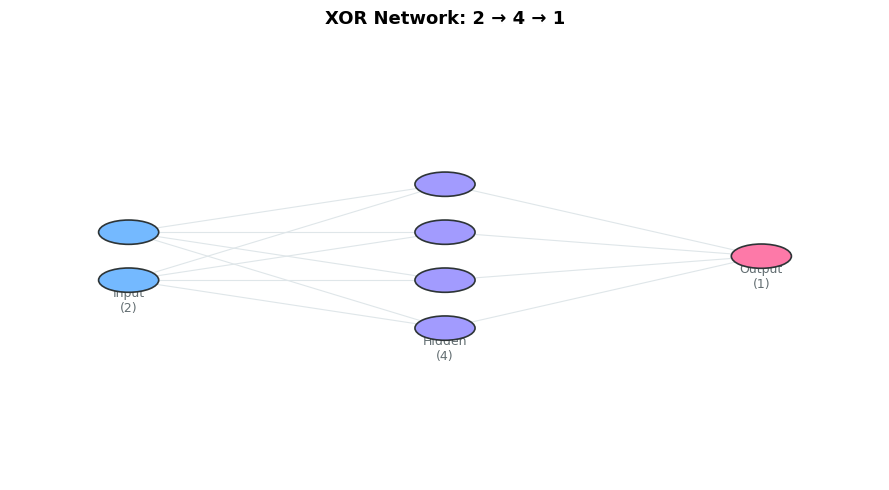

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def draw_network(layer_sizes, layer_labels=None, title='', figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.2, 1.2)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    n = len(layer_sizes)
    xs = np.linspace(0.1, 0.9, n)
    max_n = max(layer_sizes)
    gap = min(0.15, 0.85 / max(max_n, 2))
    colors = ['#74b9ff', '#a29bfe', '#fd79a8', '#55efc4', '#ffeaa7']
    ys_all = []
    for sz in layer_sizes:
        ys = [0.5 + (i - (sz - 1) / 2) * gap for i in range(sz)]
        ys_all.append(ys)
    for li in range(n - 1):
        for ya in ys_all[li]:
            for yb in ys_all[li + 1]:
                ax.plot([xs[li], xs[li + 1]], [ya, yb], color='#dfe6e9', lw=0.8, zorder=1)
    for li, (x, ys) in enumerate(zip(xs, ys_all)):
        for y in ys:
            c = plt.Circle((x, y), 0.038, fc=colors[li % len(colors)], ec='#2d3436', lw=1.2, zorder=5)
            ax.add_patch(c)
        lab = layer_labels[li] if layer_labels else str(layer_sizes[li])
        ax.text(x, min(ys) - 0.1, lab, ha='center', fontsize=9, color='#636e72')
    plt.tight_layout()
    plt.show()

draw_network(
    [2, 4, 1],
    layer_labels=['Input\n(2)', 'Hidden\n(4)', 'Output\n(1)'],
    title='XOR Network: 2 → 4 → 1'
)

## Step 9: Plot Training Loss

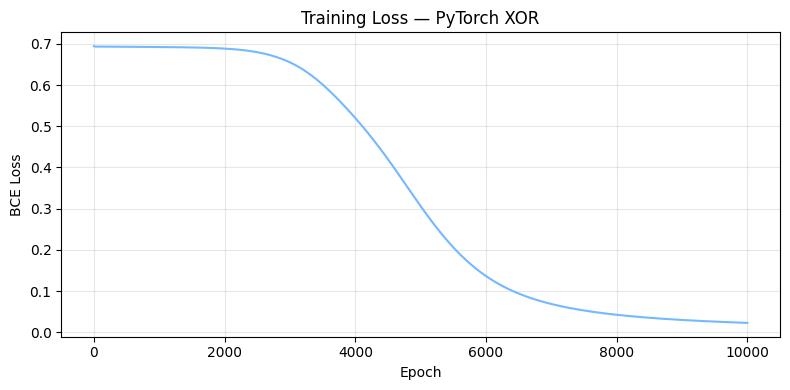

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#74b9ff', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training Loss — PyTorch XOR')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bonus: Adam optimizer

Epoch     0 | Loss: 0.7570


Epoch   500 | Loss: 0.0991


Epoch  1000 | Loss: 0.0150


Epoch  1500 | Loss: 0.0065


Epoch  2000 | Loss: 0.0037


Epoch  2500 | Loss: 0.0023


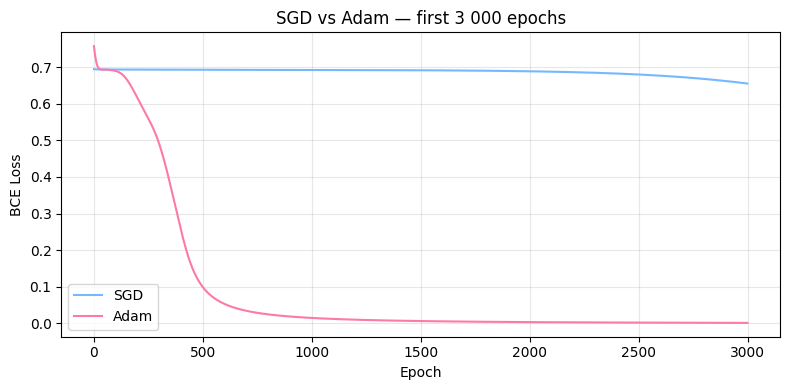

In [10]:
model2 = XORNet().to(device)
opt2   = optim.Adam(model2.parameters(), lr=0.01)
adam_losses = []
for epoch in range(3000):
    out  = model2(X)
    loss = criterion(out, y)
    opt2.zero_grad()
    loss.backward()
    opt2.step()
    adam_losses.append(loss.item())
    if epoch % 500 == 0:
        print(f'Epoch {epoch:5d} | Loss: {loss.item():.4f}')

plt.figure(figsize=(8, 4))
plt.plot(losses[:3000], label='SGD', color='#74b9ff')
plt.plot(adam_losses,   label='Adam', color='#fd79a8')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('SGD vs Adam — first 3 000 epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()